<a href="https://colab.research.google.com/github/anshulkr69/learning-to-make-machine-learn/blob/main/16-Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Random Forest:
It is a special case of bagging in which we use Decision Tree as the base model.
The name consists of "random" that comes from sampling and "forest" that comes from "group of trees".


### Bagging (Bootstrap Aggregation):
In bagging we basically train a single type of model on different samples of our original data. So intead of passing the whole data to the model, we perform sampling and pass the sampled data to multiple models.

## Special Case of Bagging:

So if the base model that we use is decision tree, it is called a Random Forest.

### Types of sampling:
1. Row Sampling:
      * with replacement: we chose the percent of rows that we want in the sample and rows can be duplicated.
      * Without replacement: we chose the percent of rows that we want in the sample and no row is duplicated.

2. Column/Feature Sampling: We chose the percentage of columns/features we want in our sample.

3. Combined Sampling: We chose both the percent of columns and rows we want in our sample.




After Sampling we pass the diferent randomly sampled data into multiple Decision tree models. To make a prediction through random forest, we pass the data point into the tables according to how ther are transformed and then return the most frequent prediction if its a classification tree and mean of all predictions if its a regression tree.

In [78]:
from sklearn.datasets import make_classification
import pandas as pd
X, y = make_classification(
    n_samples=400,
    n_features=5,            # Strictly 2 features so it maps cleanly on your screen
    n_informative=3,        # Both columns hold core signal
    n_redundant=0,
    n_clusters_per_class=2,  # Fractures the classes into 4 total cluster islands
    class_sep=0.85,          # Keeps clusters tightly packed but distinct
    flip_y=0.08,             # 8% label noise to lure unconstrained trees into overfitting
    random_state=42
)

In [79]:
df = pd.DataFrame(X, columns = ['f1','f2','f3','f4','f5'])
df['target'] = y

In [96]:
df.sample(5)

,f1,f2,f3,f4,f5,target
308,0.760139,-0.809604,0.603308,0.424061,1.369274,1
248,-1.133614,-0.098588,-1.828217,0.018850,-0.994082,0
73,-1.483080,0.119580,-1.460530,-0.973069,1.383708,0
221,-0.998670,0.708214,-1.144391,0.233216,-0.376124,0
358,2.050956,-1.683438,-0.673651,-0.805870,0.691676,1


In [81]:
def sample_rows(df, percent):
  df_new = df.sample(int(percent * df.shape[0]), replace = True)
  return df_new

In [82]:
import numpy as np
import random
def sample_features(df, percent):
  df_new = random.sample(df.columns.tolist()[:-1], int(percent * (df.shape[1]-1)))
  df_new['target'] = df.iloc[:,-1]
  return df_new

In [83]:
def sample_combined(df, percent_row, percent_feature):
  df_new = sample_features(sample_rows(df, percent_row),percent_feature)
  return df_new

In [84]:
df1 = sample_rows(df, 0.5)

In [85]:
df2 = sample_rows(df, 0.5)

In [86]:
df3 = sample_rows(df, 0.5)

In [87]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

clf1 = DecisionTreeClassifier(min_samples_leaf = 5)
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])

DecisionTreeClassifier(min_samples_leaf=5)

In [88]:
clf2 = DecisionTreeClassifier(min_samples_leaf = 5)
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])

DecisionTreeClassifier(min_samples_leaf=5)

In [89]:
clf3 = DecisionTreeClassifier(min_samples_leaf = 5)
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier(min_samples_leaf=5)

[Text(0.42, 0.9375, 'x[0] <= -0.485\ngini = 0.5\nsamples = 200\nvalue = [103, 97]'),
 Text(0.16, 0.8125, 'x[2] <= -0.175\ngini = 0.306\nsamples = 85\nvalue = [69, 16]'),
 Text(0.29, 0.875, 'True  '),
 Text(0.08, 0.6875, 'x[1] <= 0.498\ngini = 0.068\nsamples = 57\nvalue = [55, 2]'),
 Text(0.04, 0.5625, 'gini = 0.0\nsamples = 48\nvalue = [48, 0]'),
 Text(0.12, 0.5625, 'gini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.24, 0.6875, 'x[2] <= -0.026\ngini = 0.5\nsamples = 28\nvalue = [14, 14]'),
 Text(0.2, 0.5625, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.28, 0.5625, 'x[1] <= -0.094\ngini = 0.463\nsamples = 22\nvalue = [14, 8]'),
 Text(0.24, 0.4375, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.32, 0.4375, 'x[4] <= 0.13\ngini = 0.498\nsamples = 17\nvalue = [9, 8]'),
 Text(0.28, 0.3125, 'gini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.36, 0.3125, 'gini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.68, 0.8125, 'x[4] <= 0.225\ngini = 0.416\nsamples = 115\nvalue = [34, 

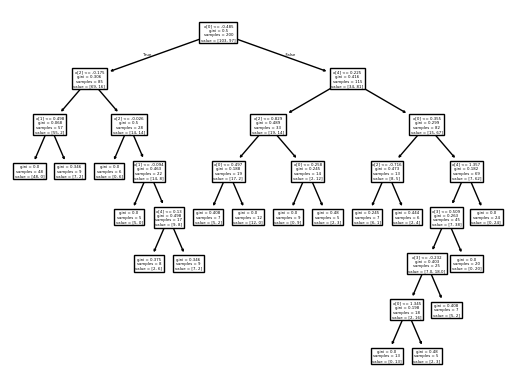

In [90]:
plot_tree(clf1)

[Text(0.5131578947368421, 0.9375, 'x[0] <= -0.118\ngini = 0.5\nsamples = 200\nvalue = [101, 99]'),
 Text(0.34210526315789475, 0.8125, 'x[2] <= 0.008\ngini = 0.3\nsamples = 98\nvalue = [80, 18]'),
 Text(0.4276315789473685, 0.875, 'True  '),
 Text(0.21052631578947367, 0.6875, 'x[1] <= 0.536\ngini = 0.144\nsamples = 77\nvalue = [71, 6]'),
 Text(0.10526315789473684, 0.5625, 'x[2] <= -0.281\ngini = 0.032\nsamples = 61\nvalue = [60, 1]'),
 Text(0.05263157894736842, 0.4375, 'gini = 0.0\nsamples = 55\nvalue = [55, 0]'),
 Text(0.15789473684210525, 0.4375, 'gini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.3157894736842105, 0.5625, 'x[4] <= 0.444\ngini = 0.43\nsamples = 16\nvalue = [11, 5]'),
 Text(0.2631578947368421, 0.4375, 'x[4] <= -0.307\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.21052631578947367, 0.3125, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.3157894736842105, 0.3125, 'gini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.3684210526315789, 0.4375, 'gini = 0.444\nsa

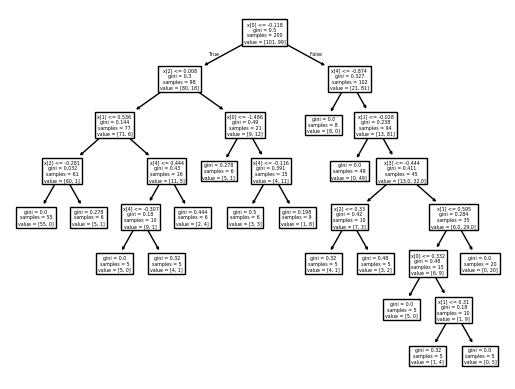

In [91]:
plot_tree(clf2)

[Text(0.4, 0.95, 'x[0] <= -0.538\ngini = 0.495\nsamples = 200\nvalue = [110.0, 90.0]'),
 Text(0.2, 0.85, 'x[0] <= -0.878\ngini = 0.134\nsamples = 83\nvalue = [77, 6]'),
 Text(0.30000000000000004, 0.8999999999999999, 'True  '),
 Text(0.1, 0.75, 'x[1] <= 0.83\ngini = 0.031\nsamples = 63\nvalue = [62, 1]'),
 Text(0.05, 0.65, 'gini = 0.0\nsamples = 55\nvalue = [55, 0]'),
 Text(0.15, 0.65, 'gini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.3, 0.75, 'x[2] <= -0.339\ngini = 0.375\nsamples = 20\nvalue = [15, 5]'),
 Text(0.25, 0.65, 'x[2] <= -0.957\ngini = 0.142\nsamples = 13\nvalue = [12, 1]'),
 Text(0.2, 0.55, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.3, 0.55, 'gini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.35, 0.65, 'gini = 0.49\nsamples = 7\nvalue = [3, 4]'),
 Text(0.6, 0.85, 'x[4] <= -0.646\ngini = 0.405\nsamples = 117\nvalue = [33, 84]'),
 Text(0.5, 0.8999999999999999, '  False'),
 Text(0.5, 0.75, 'x[0] <= -0.154\ngini = 0.231\nsamples = 15\nvalue = [13, 2]'),
 Text(0.45

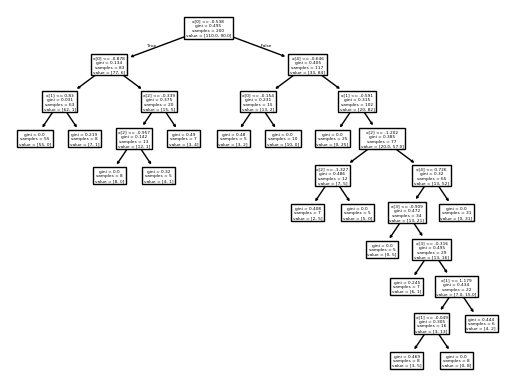

In [92]:
plot_tree(clf3)

In [100]:
clf1.predict(np.array([-0.998670,	0.708214,	-1.144391,	0.233216,	-0.376124]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [101]:
clf2.predict(np.array([-0.998670,	0.708214,	-1.144391,	0.233216,	-0.376124]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [102]:
clf3.predict(np.array([-0.998670,	0.708214,	-1.144391,	0.233216,	-0.376124]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])